In [1]:
import duckdb

In [2]:
# Database connection
con = duckdb.connect("retail_db.duckdb")

### Data Overview

In [3]:
# list of Fact Tables:
# 1. fact_sales
# 2. fact_purchage
# 3. fact_begin_to_end_inventory
# 4. fact_end_to_begin_inventory
# 5. fact_vendor_invoice


# list of Dimension Tables:
# 1. dim_brand_purchase_sales
# 2. dim_vendor
# 3. dim_store
# 4. dim_inventory
# 5. dim_brand_inventory
# 6. dim_date

In [4]:
# Row counts
all_rows_count = """
select 'fact_sales' as table, count(*) from fact_sales
union all
select 'fact_purchage' as table, count(*) from fact_purchage
union all
select 'fact_vendor_invoice' as table, count(*) from fact_vendor_invoice
union all
select 'fact_begin_to_end_inventory' as table, count(*) from fact_begin_to_end_inventory
union all
select 'fact_end_to_begin_inventory' as table, count(*) from fact_end_to_begin_inventory;
"""

con.execute(all_rows_count).df()

,table,count_star()
0,fact_sales,12825363
1,fact_purchage,2372474
2,fact_vendor_invoice,5543
3,fact_begin_to_end_inventory,206529
4,fact_end_to_begin_inventory,224489


In [5]:
# Null check - Fact_Sales
null_check_sales = """
select 
    sum(case when Brand_ID is null then 1 else 0 end) as null_brand,
    sum(case when vendor_id is null then 1 else 0 end) as null_vendor,
    sum(case when store_id is null then 1 else 0 end) as null_store,
    sum(case when date_id is null then 1 else 0 end) as null_date,
    sum(case when SalesQuantity is null then 1 else 0 end) as null_sales_qty,
    sum(case when SalesDollars is null then 1 else 0 end) as null_sales_doller,
    sum(case when SalesPrice is null then 1 else 0 end) as null_sales_proce
from fact_sales;
"""

con.execute(null_check_sales).df()

,null_brand,null_vendor,null_store,null_date,null_sales_qty,null_sales_doller,null_sales_proce
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
# Null check - Fact_Purchase
null_check_purchase = """
select 
    sum(case when inv_date_id is null then 1 else 0 end) as null_inv_date,
    sum(case when pay_date_id is null then 1 else 0 end) as null_pay_date,
    sum(case when inventory_id is null then 1 else 0 end) as null_inventory,
    sum(case when PurchasePrice is null then 1 else 0 end) as null_purchase_price,
    sum(case when Quantity is null then 1 else 0 end) as null_quentity,
    sum(case when Dollars is null then 1 else 0 end) as null_doller
from fact_purchage;
"""
con.execute(null_check_purchase).df()

,null_inv_date,null_pay_date,null_inventory,null_purchase_price,null_quentity,null_doller
0,0.0,0.0,0.0,0.0,0.0,0.0


### Sales Performance

##### 1. Top Brand by Revenue

In [7]:
print(con.execute('select * from dim_date limit 3').fetch_df())

   date_id  full_date  year  month  day
0        1 2023-12-20  2023     12   20
1        2 2023-12-21  2023     12   21
2        3 2023-12-22  2023     12   22


In [8]:
top_brand_by_revenue = """
select s.Brand, s.Description as brand_name, cast(sum(s.SalesDollars) as decimal(15, 2)) as total_sales
from fact_sales s
join dim_brand_purchase_sales b on s.Brand_ID = b.Brand_ID
group by s.Brand, brand_name
order by total_sales DESC
limit 20;
"""

con.execute(top_brand_by_revenue).df()

,Brand,brand_name,total_sales
0,1233,Jack Daniels No 7 Black,5101919.51
1,3405,Tito's Handmade Vodka,4819073.49
2,8068,Absolut 80 Proof,4538120.60
3,4261,Capt Morgan Spiced Rum,4475972.88
4,3545,Ketel One Vodka,4223107.62
5,3858,Grey Goose Vodka,3383912.40
6,2589,Jameson Irish Whiskey,2773367.73
7,3489,Tanqueray,2640491.19
8,3102,Smirnoff Traveler,2592041.35
9,1376,Jim Beam,2435393.39


##### 2. Sales trend overview

In [9]:
sales_trend = """
select d.year, d.month, cast(sum(s.SalesDollars) as decimal(15, 2)) as monthly_sales
from fact_sales s
join dim_date d on s.date_id = d.date_id
group by d.year, d.month
order by d.year, d.month;
"""

con.execute(sales_trend).df()

,year,month,monthly_sales
0,2024,1,29854027.92
1,2024,2,28876607.23
2,2024,3,28988411.94
3,2024,4,30723734.63
4,2024,5,36041210.52
5,2024,6,39290701.46
6,2024,7,49696466.85
7,2024,8,39056166.03
8,2024,9,38477538.83
9,2024,10,36433141.73


### Purchase & Cost Analysis

##### 1. Top vendors by spend

In [10]:
fact_purchase = '''
describe fact_purchage;
'''
dim_vendor = '''
select * from dim_vendor limit 2;
'''
fact_sales = '''
describe fact_sales;
'''
print(con.execute(fact_sales).df())

       column_name   column_type null   key default extra
0       SalesPrice        DOUBLE  YES  None    None  None
1         store_id      UINTEGER  YES  None    None  None
2     SalesDollars        DOUBLE  YES  None    None  None
3        vendor_id      UINTEGER  YES  None    None  None
4         VendorNo        BIGINT  YES  None    None  None
5        ExciseTax        DOUBLE  YES  None    None  None
6            month       TINYINT  YES  None    None  None
7      InventoryId       VARCHAR  YES  None    None  None
8            Brand        BIGINT  YES  None    None  None
9            Store        BIGINT  YES  None    None  None
10      VendorName       VARCHAR  YES  None    None  None
11        Brand_ID      UINTEGER  YES  None    None  None
12   SalesQuantity        BIGINT  YES  None    None  None
13             day       TINYINT  YES  None    None  None
14    inventory_id      UINTEGER  YES  None    None  None
15            year       INTEGER  YES  None    None  None
16     Descrip

In [11]:
top_vendor_spend = '''
select v.VendorNumber, cast(sum(f.Dollars) as decimal(15, 2)) as total_purchase
from fact_purchage f
join dim_vendor v on f.VendorNumber = v.VendorNumber
group by v.VendorNumber
order by total_purchase DESC
limit 10;
'''
con.execute(top_vendor_spend).df()

,VendorNumber,total_purchase
0,3960,50959796.85
1,4425,27861690.02
2,12546,24203151.05
3,17035,24124091.56
4,480,17624378.72
5,1392,15573917.90
6,1128,13529433.08
7,9165,13210613.93
8,3252,12289608.09
9,9552,10935817.30


##### 2. Average Purchase price vs sales price

In [12]:
average_purchase_sales = '''
select b.Brand_ID, b.Brand,
    cast(AVG(s.SalesPrice) as decimal(15, 2)) as avg_sales_price,
    cast(AVG(p.PurchasePrice) as decimal(15, 2)) as avg_purchase_price,
    avg_sales_price - avg_purchase_price as avg_profit_margin
from fact_sales s
join fact_purchage p on s.Brand_ID = p.Brand_ID
join dim_brand_purchase_sales b on s.Brand_ID = b.Brand_ID
group by b.Brand_ID, b.Brand
limit 10;
'''

con.execute(average_purchase_sales).df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,Brand_ID,Brand,avg_sales_price,avg_purchase_price,avg_profit_margin
0,6018,3893,9.99,7.93,2.06
1,3526,3913,18.62,14.28,4.34
2,1844,39384,15.07,8.96,6.11
3,1879,3987,11.15,8.65,2.50
4,10848,40098,18.90,10.38,8.52
5,299,4103,14.34,11.19,3.15
6,9865,4141,0.99,0.71,0.28
7,5896,4152,5.60,3.75,1.85
8,10662,41530,9.55,5.84,3.71
9,2031,4157,0.99,0.72,0.27


> Insights: Address profit margin and overpriced brands. Though this result consider only 10 random records. 

##### 3. Vendor invoice validation
##### Check if vendor invoice match purchase orders (financial accuracy)

In [13]:
# list of Fact Tables:
# 2. fact_purchage
# 5. fact_vendor_invoice


# list of Dimension Tables:
# 2. dim_vendor

In [14]:
fact_purchase = '''
describe fact_purchage;
'''
dim_vendor = '''
select * from dim_vendor limit 2;
'''
fact_vendor_invoice = '''
select * from fact_vendor_invoice limit 2;
'''
con.execute(fact_vendor_invoice).df()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval,vendor_id
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None,56
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None,1


In [15]:
vendor_invoice_validation = '''
with calculate_validation as (
    select
        f.VendorNumber as vendor_No, f.VendorName as vendor_name,
        cast(sum(f.Dollars) as decimal(15, 2)) as total_invoiced_amount,
        cast(sum(p.Dollars) as decimal(15, 2)) as total_purchased_amount
    from fact_vendor_invoice f
    join fact_purchage p on f.PONumber = p.PONumber
    join dim_vendor v on f.vendor_id = v.vendor_id
    --where f.PONumber = 8124
    group by f.VendorNumber, f.VendorName
)

select vendor_No, vendor_name, 
    format(cast(total_invoiced_amount as varchar), '###,###,##0.00') as total_invoiced,
    format(cast(total_purchased_amount as varchar), '###,###,##0.00') as total_purchased,
    format(cast(total_invoiced_amount - total_purchased_amount AS VARCHAR), '###,###,##0.00') as diff
from calculate_validation
order by diff DESC
limit 10;
'''

con.execute(vendor_invoice_validation).df()

,vendor_No,vendor_name,total_invoiced,total_purchased,diff
0,6215,MOONLIGHT MEADERY,11266190.91,1314152.10,9952038.81
1,8352,LUXCO INC,994730055.79,1971131.51,992758924.28
2,7239,REMY COINTREAU USA INC,991867451.74,3055485.83,988811965.91
3,173357,TAMWORTH DISTILLING,1451221.08,486074.39,965146.69
4,8320,SHAW ROSS INT L IMP LTD,95782935.93,732927.11,95050008.82
5,90059,BLACK COVE BEVERAGES,1215930.74,309129.09,906801.65
6,9815,WINE GROUP INC,8817759785.89,5590740.32,8812169045.57
7,90027,POVERTY LANE ORCHARDS,9894662.98,1163975.51,8730687.47
8,3950,"HOOD RIVER DISTILLERS, Inc.",570301.24,483011.13,87290.11
9,388,ATLANTIC IMPORTING COMPANY,10299324.20,1672699.57,8626624.63


In [16]:
fact_purchase = '''
select PONumber, PurchasePrice, Quantity, Dollars from fact_purchage where PONumber=8124;
'''
con.execute(fact_purchase).df()

,PONumber,PurchasePrice,Quantity,Dollars
0,8124,35.71,6,214.26


> Insights: Overbilling or Underbilling or Missing invoices

### Inventory Utilization
##### 1. Stock vs Sales

In [17]:
# list of Fact Tables:
# 1. fact_sales
# 2. fact_purchage
# 3. fact_begin_to_end_inventory
# 4. fact_end_to_begin_inventory
# 5. fact_vendor_invoice


# list of Dimension Tables:
# 1. dim_brand_purchase_sales
# 2. dim_vendor
# 3. dim_store
# 4. dim_inventory
# 5. dim_brand_inventory
# 6. dim_date

In [18]:
fact_end_begin_inventory = '''
select max(endDate_end), min(endDate_end) from fact_end_to_begin_inventory limit 2;
'''
con.execute(fact_end_begin_inventory).df()

,max(endDate_end),min(endDate_end)
0,2024-12-31,2024-12-31


In [19]:
fact_begin_to_end_inventory = '''
select max(startDate_start), min(startDate_start) from fact_begin_to_end_inventory limit 2;
'''
con.execute(fact_begin_to_end_inventory).df()

,max(startDate_start),min(startDate_start)
0,2024-01-01,2024-01-01


* Stock count on January, 2024

In [20]:
con.execute('select InventoryId, Store_start, Brand_start, Size_start, onHand_start, Price_start, Brand_end, onHand_end, Price_end from  fact_begin_to_end_inventory').df()

,InventoryId,Store_start,Brand_start,Size_start,onHand_start,Price_start,Brand_end,onHand_end,Price_end
0,1_HARDERSFIELD_58,1,58,750mL,8,12.99,58.0,11.0,12.99
1,1_HARDERSFIELD_60,1,60,750mL,7,10.99,NaN,NaN,NaN
2,1_HARDERSFIELD_62,1,62,750mL,6,36.99,62.0,7.0,36.99
3,1_HARDERSFIELD_63,1,63,750mL,3,38.99,63.0,7.0,38.99
4,1_HARDERSFIELD_72,1,72,750mL,6,34.99,72.0,4.0,34.99
...,...,...,...,...,...,...,...,...,...
206524,79_BALLYMENA_46985,79,46985,750mL,13,22.99,46985.0,44.0,23.99
206525,79_BALLYMENA_47014,79,47014,750mL,13,13.99,47014.0,9.0,13.99
206526,79_BALLYMENA_47090,79,47090,750mL,19,23.99,47090.0,14.0,23.99
206527,79_BALLYMENA_90011,79,90011,750mL,12,144.99,90011.0,9.0,144.99


In [21]:
con.execute('describe fact_end_to_begin_inventory').df()

,column_name,column_type,null,key,default,extra
0,InventoryId,VARCHAR,YES,None,None,None
1,Store_end,BIGINT,YES,None,None,None
2,City_end,VARCHAR,YES,None,None,None
3,Brand_end,BIGINT,YES,None,None,None
4,Description_end,VARCHAR,YES,None,None,None
5,Size_end,VARCHAR,YES,None,None,None
6,onHand_end,BIGINT,YES,None,None,None
7,Price_end,DOUBLE,YES,None,None,None
8,endDate_end,TIMESTAMP_MS,YES,None,None,None
9,Brand_ID_end,DOUBLE,YES,None,None,None


In [22]:
begining_inventory_turnover_ratio = '''
select b.Brand_ID, 
sum(f.onHand_start) as stock_available,
sum(s.SalesQuantity) as sales_qty,
COALESCE((sales_qty / NULLIF(stock_available, 0)) * 100, 0) as turnover_ratio
from fact_begin_to_end_inventory f
left join fact_sales s on f.Brand_ID_start = s.Brand_ID
join dim_brand_purchase_sales b on f.Brand_ID_start = b.Brand_ID
where month(f.startDate_start) in (1)
group by b.Brand_ID
order by turnover_ratio DESC;
'''

con.execute(begining_inventory_turnover_ratio).df()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,Brand_ID,stock_available,sales_qty,turnover_ratio
0,1469,11653.0,3844736.0,32993.529563
1,551,36.0,1064.0,2955.555556
2,33,2.0,50.0,2500.000000
3,683,105.0,1880.0,1790.476190
4,11327,4.0,68.0,1700.000000
...,...,...,...,...
8019,5663,0.0,1.0,0.000000
8020,8867,0.0,1.0,0.000000
8021,2878,0.0,25480.0,0.000000
8022,6518,0.0,152.0,0.000000


* Stock count on December, 2024

In [23]:
end_inventory_turnover_ratio = '''
select b.Brand_ID, 
sum(f.onHand_end) as stock_available,
sum(COALESCE(TRY_CAST(s.SalesQuantity as DECIMAL), 0)) as sales_qty,
COALESCE((sales_qty / NULLIF(stock_available, 0)) * 100, 0) as turnover_ratio
from fact_end_to_begin_inventory f
left join fact_sales s on f.Brand_ID_end = s.Brand_ID
join dim_brand_purchase_sales b on f.Brand_ID_end = b.Brand_ID
where month(f.endDate_end) in (12)
group by b.Brand_ID
order by turnover_ratio DESC;
'''

con.execute(end_inventory_turnover_ratio).df()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,Brand_ID,stock_available,sales_qty,turnover_ratio
0,3964,513.0,59584.0,11614.814815
1,4613,164.0,5811.0,3543.292683
2,7081,4735.0,141329.0,2984.772967
3,2144,657.0,14250.0,2168.949772
4,1589,234.0,3740.0,1598.290598
...,...,...,...,...
9576,2292,35.0,0.0,0.000000
9577,1179,12.0,0.0,0.000000
9578,9690,6.0,0.0,0.000000
9579,831,252.0,0.0,0.000000


> Insight: Which products are overstocked vs Understocked
If we go throught the January and December stock count, it shows there are many items which are not stocked in inventory by lots of items are sold.
And there are many items which are completly unsold.

### Growth  Profitability
##### 1. Month-over-month sales growth

In [24]:
# list of Fact Tables:
# 1. fact_sales
# 2. fact_purchage
# 3. fact_vendor_invoice


# list of Dimension Tables:
# 1. dim_brand_purchase_sales
# 2. dim_vendor
# 6. dim_date

In [25]:
mom_sales_growth = '''
with monthly_sales as (
select d.year, d.month,
cast(sum(s.SalesDollars) as decimal(15, 2)) as sales_amount,
LAG(sales_amount, 1, 0) over (order by d.year, d.month) as previous_sales_amount,
from fact_sales s
join dim_date d on s.date_id = d.date_id
group by d.year, d.month
)

select ms.year, ms.month, ms.sales_amount, ms.previous_sales_amount,
case
    when ms.previous_sales_amount = 0 and ms.sales_amount > 0 then 0
    when ms.previous_sales_amount = 0 and ms.sales_amount <= 0 then NULL
    else round(
        ((ms.sales_amount - ms.previous_sales_amount) * 100) / ms.previous_sales_amount,
    2)
end as mom_growth_rate
from monthly_sales ms
order by ms.year, ms.month;
'''

con.execute(mom_sales_growth).df()


,year,month,sales_amount,previous_sales_amount,mom_growth_rate
0,2024,1,29854027.92,0.00,0.00
1,2024,2,28876607.23,29854027.92,-3.27
2,2024,3,28988411.94,28876607.23,0.39
3,2024,4,30723734.63,28988411.94,5.99
4,2024,5,36041210.52,30723734.63,17.31
5,2024,6,39290701.46,36041210.52,9.02
6,2024,7,49696466.85,39290701.46,26.48
7,2024,8,39056166.03,49696466.85,-21.41
8,2024,9,38477538.83,39056166.03,-1.48
9,2024,10,36433141.73,38477538.83,-5.31


##### 1. Sales Margin

In [26]:
con.execute('describe fact_sales').df()

,column_name,column_type,null,key,default,extra
0,SalesPrice,DOUBLE,YES,None,None,None
1,store_id,UINTEGER,YES,None,None,None
2,SalesDollars,DOUBLE,YES,None,None,None
3,vendor_id,UINTEGER,YES,None,None,None
4,VendorNo,BIGINT,YES,None,None,None
5,ExciseTax,DOUBLE,YES,None,None,None
6,month,TINYINT,YES,None,None,None
7,InventoryId,VARCHAR,YES,None,None,None
8,Brand,BIGINT,YES,None,None,None
9,Store,BIGINT,YES,None,None,None


In [27]:
sales_margin = '''
select 
s.Brand_ID, s.Description as brand_name, s.VendorName, s.SalesDate, d.month,
s.SalesPrice as total_sales_price,
p.PurchasePrice as total_purchase_price,
i.Freight as freight_cost,
i.Quantity as total_qty,
freight_cost / total_qty as item_per_freight_cost,
total_sales_price - (total_purchase_price + item_per_freight_cost) as sales_margin
from fact_sales s
join fact_purchage p on s.Brand_ID = p.Brand_ID
join fact_vendor_invoice i on p.PONumber = i.PONumber
join dim_brand_purchase_sales b on s.Brand_ID = b.Brand_ID
join dim_date d on s.date_id = d.month
limit 10;
'''

con.execute(sales_margin).df()

,Brand_ID,brand_name,VendorName,SalesDate,month,total_sales_price,total_purchase_price,freight_cost,total_qty,item_per_freight_cost,sales_margin
0,2113,Jim Beam w/2 Rocks Glasses,JIM BEAM BRANDS COMPANY,2024-01-01,12,16.49,10.65,9.19,96,0.095729,5.744271
1,5826,Terroirs du Rhone,PERFECTA WINES,2024-01-01,12,8.99,6.03,284.63,6713,0.042400,2.917600
2,10873,Almaden Mt Rhine Calif B/B,WINE GROUP INC,2024-01-01,12,14.99,9.86,630.96,20396,0.030935,5.099065
3,562,Jack Daniels Bruins Glass Pk,BROWN-FORMAN CORP,2024-01-01,12,27.99,21.70,1494.51,23351,0.064002,6.225998
4,9125,W Hill RSV Cab Svgn,E & J GALLO WINERY,2024-01-01,12,42.99,28.10,10.38,111,0.093514,14.796486
5,6441,Caymus Cab Svgn Napa Vly,MARTIGNETTI COMPANIES,2024-01-01,12,74.99,50.33,3061.37,59863,0.051140,24.608860
6,10500,Penfolds Koonunga Hills Shir,MARTIGNETTI COMPANIES,2024-01-01,12,10.99,7.53,1657.99,29819,0.055602,3.404398
7,1391,DiSaronna Amaretto Sour VAP,DISARONNO INTERNATIONAL LLC,2024-01-01,12,19.99,14.38,143.74,2423,0.059323,5.550677
8,8213,M & R Sparkling Rose,BACARDI USA INC,2024-01-01,12,9.99,6.66,1.75,36,0.048611,3.281389
9,9758,The Glenlivet 12 Yr Single,PERNOD RICARD USA,2024-01-01,12,4.99,3.56,1162.80,36745,0.031645,1.398355


### Sales Trends

In [28]:
# list of Fact Tables:
# 1. fact_sales
# 2. fact_purchage
# 3. fact_begin_to_end_inventory
# 4. fact_end_to_begin_inventory
# 5. fact_vendor_invoice


# list of Dimension Tables:
# 1. dim_brand_purchase_sales
# 2. dim_vendor
# 3. dim_store
# 4. dim_inventory
# 5. dim_brand_inventory
# 6. dim_date

* ##### Sales over time

In [29]:
import matplotlib.pyplot as plt
import polars as pl
import calendar

In [73]:
con.execute('describe fact_purchage').df()

,column_name,column_type,null,key,default,extra
0,InventoryId,VARCHAR,YES,None,None,None
1,Store,BIGINT,YES,None,None,None
2,Brand,BIGINT,YES,None,None,None
3,Description,VARCHAR,YES,None,None,None
4,Size,VARCHAR,YES,None,None,None
5,VendorNumber,BIGINT,YES,None,None,None
6,VendorName,VARCHAR,YES,None,None,None
7,PONumber,BIGINT,YES,None,None,None
8,PODate,TIMESTAMP_MS,YES,None,None,None
9,ReceivingDate,TIMESTAMP_MS,YES,None,None,None


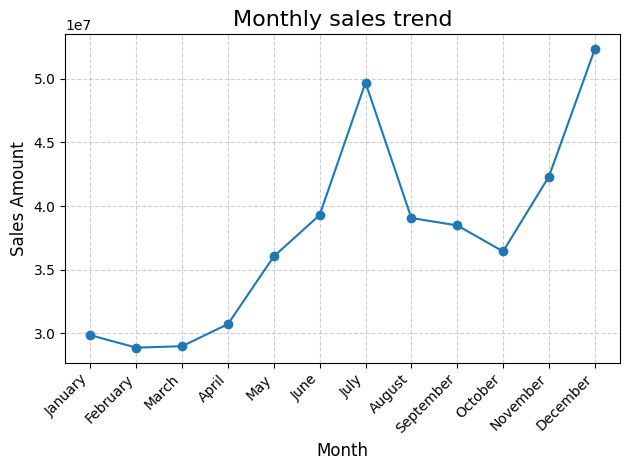

In [45]:
# Query
sales_over_time_query = '''
select 
    d.year, d.month, 
    cast(sum(s.SalesDollars) as decimal(15, 2)) as sales
from fact_sales s
join dim_date d on s.date_id = d.date_id
group by d.year, d.month
order by d.year, d.month;
'''
# Execute query - shoe the result output
sales_over_time = con.execute(sales_over_time_query).pl()

# add new column named month_name
sales_over_time = sales_over_time.with_columns(
    pl.col('month').map_elements(lambda x: calendar.month_name[x]).alias('month_name')
)

months = sales_over_time['month_name'].to_list()
sales = sales_over_time['sales'].to_list()

plt.Figure(figsize=(12, 6))
plt.plot(months, sales, marker='o', linestyle='-')
plt.title('Monthly sales trend', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Sales Amount', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

* ##### Spend by vendor

<Figure size 1200x700 with 0 Axes>

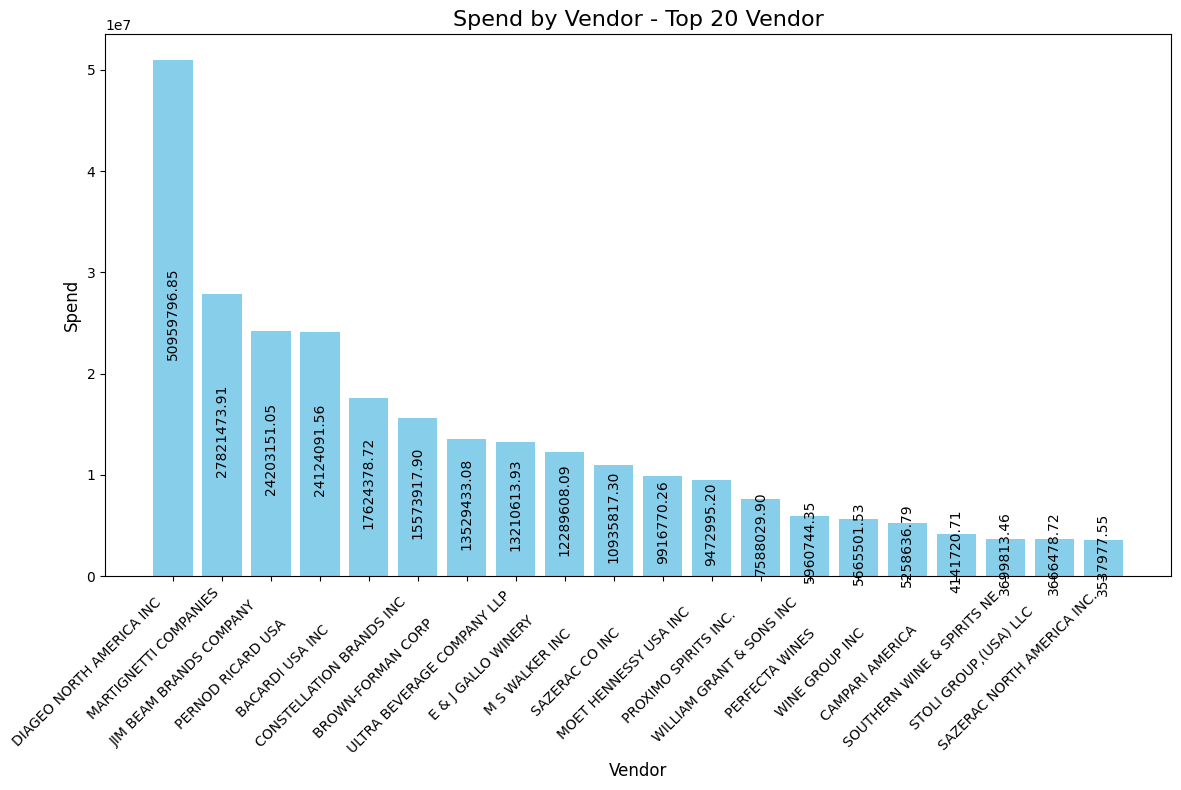

In [55]:
spend_byvendor_query = '''
select v.vendor_id, p.VendorName, 
    cast(sum(p.Dollars) as decimal(15, 2)) as total_spend
from fact_purchage p
join dim_vendor v on p.vendor_id = v.vendor_id
group by v.vendor_id, p.VendorName
order by total_spend DESC
limit 20;
'''

spend_by_vendor = con.execute(spend_byvendor_query).pl()
spend_by_vendor

vendors = spend_by_vendor['VendorName'].to_list()
spend = spend_by_vendor['total_spend'].to_list()

plt.figure(figsize=(12, 7))
fig, ax = plt.subplots(figsize=(12, 8))
#plt.bar(vendors, spend, color='skyblue')
bars = ax.bar(vendors, spend, color='skyblue')
ax.bar_label(bars, fmt='%.2f', rotation=90, label_type='center', padding=3)
plt.title('Spend by Vendor - Top 20 Vendor', fontsize=16)
plt.xlabel('Vendor', fontsize=12)
plt.ylabel('Spend', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

* ##### Distribution of purchase prices per brand (detect overpriced vendors).

C:\Users\tanvi\AppData\Local\Temp\ipykernel_9152\2358318845.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(grouped_prices, labels=brands, patch_artist=True, medianprops={'color': 'black'})


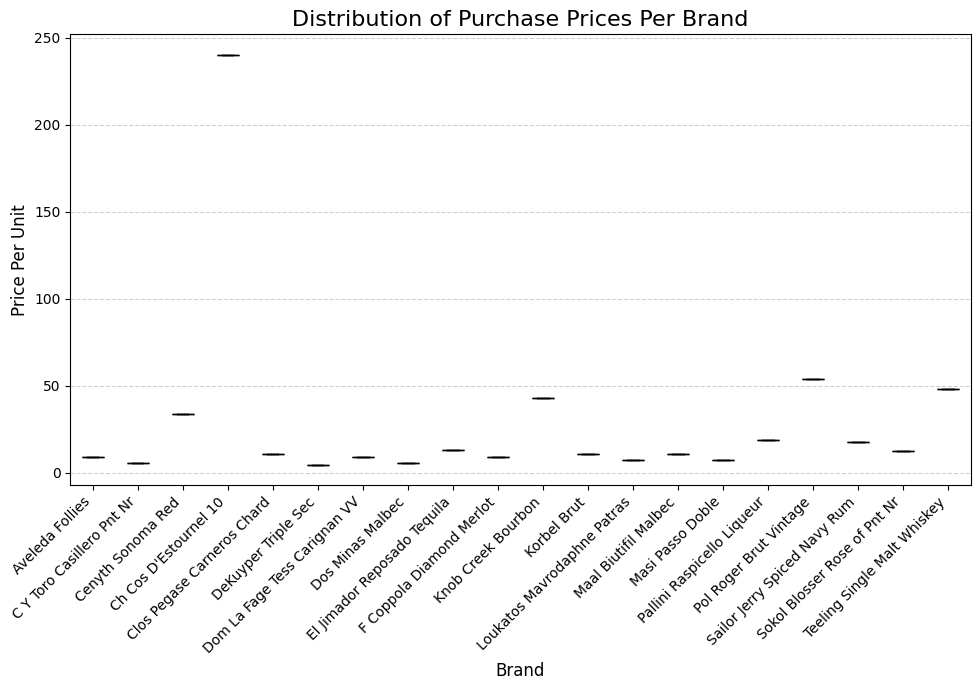

In [71]:
brand_overpriced_vendor_query = '''
select b.Brand_ID, p.Description as brand_name, p.PurchasePrice
from fact_purchage p 
join dim_brand_purchase_sales b on p.Brand_ID = b.Brand_ID
order by b.Brand_ID, brand_name
limit 5000;
'''

brand_overpriced_vendor = con.execute(brand_overpriced_vendor_query).pl()
#brand_overpriced_vendor

# First, get the unique, sorted list of brands.
# Correct: `unique().to_list()`
# Incorrect: `unique().list()`
brands = sorted(brand_overpriced_vendor['brand_name'].unique().to_list())

# Then, use this list to iterate and create the list of prices for each brand.
grouped_prices = [
    brand_overpriced_vendor.filter(pl.col("brand_name") == b)['PurchasePrice'].to_list()
    for b in brands
]

fig, ax = plt.subplots(figsize=(10, 7))
ax.boxplot(grouped_prices, labels=brands, patch_artist=True, medianprops={'color': 'black'})

# 5. Customize the plot for better readability
ax.set_title("Distribution of Purchase Prices Per Brand", fontsize=16)
ax.set_xlabel("Brand", fontsize=12)
ax.set_ylabel("Price Per Unit", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

* ##### Gross margin per brand.

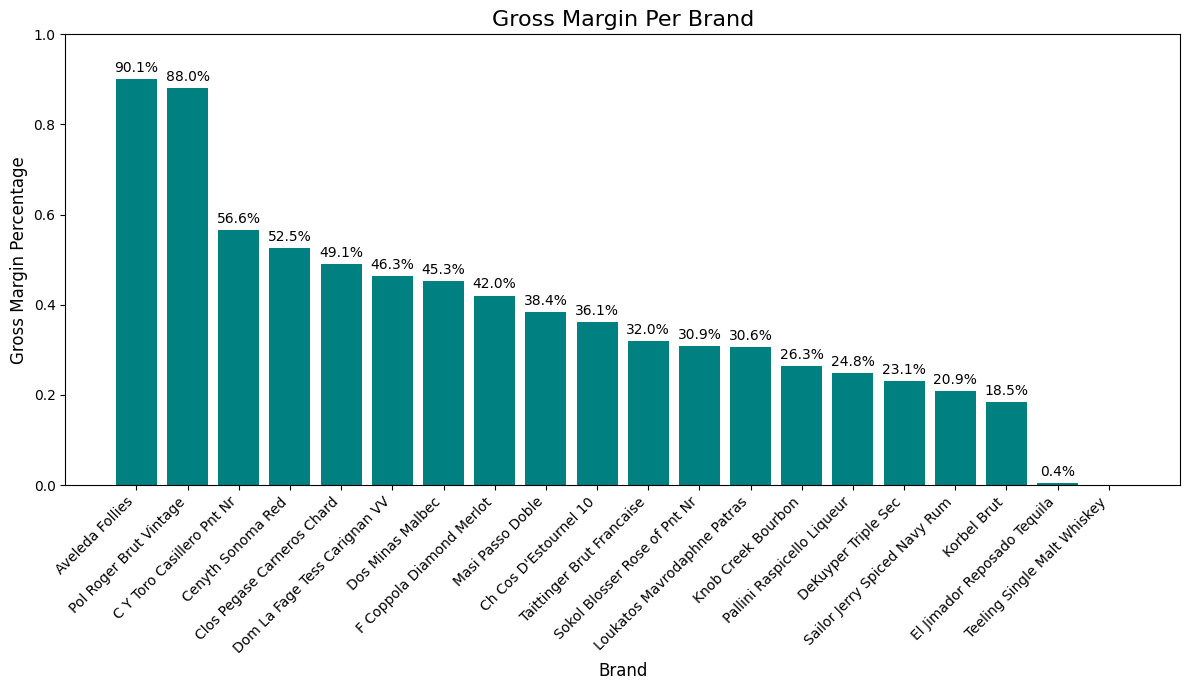

In [92]:
gross_margin_per_brand_query = '''
with BrandSales as (
    select s.Brand_ID, s.Description,
    sum(s.SalesDollars) as toatl_revenue
    from fact_sales s
    group by s.Brand_ID, s.Description
),

BrandPurchase as (
    select p.Brand_ID, p.Description,
    sum(p.Dollars) as cogs
    from fact_purchage p
    group by p.Brand_ID, p.Description
)

select b.Brand_ID, bs.Description as brand, bs.toatl_revenue, bp.cogs
from dim_brand_purchase_sales b
join BrandSales bs on b.Brand_ID = bs.Brand_ID
join BrandPurchase bp on b.Brand_ID = bp.Brand_ID
order by b.Brand_ID
limit 20;
'''

gross_margin_per_brand = con.execute(gross_margin_per_brand_query).pl()

# Calculate gross margin per brand 
gross_margin_per_brand = gross_margin_per_brand.with_columns(
    ((pl.col('toatl_revenue') - pl.col('cogs')) / pl.col('toatl_revenue')).alias('gross_margin')
)

gross_margin_per_brand = gross_margin_per_brand.sort('gross_margin', descending=True)

# Extranct column as list for ploting
brands = gross_margin_per_brand['brand'].to_list()
gross_margin = gross_margin_per_brand['gross_margin'].to_list()

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.bar(brands, gross_margin, color='teal')

# Use a lambda function for custom formatting with percentage and 1 decimal place
ax.bar_label(bars, fmt=lambda x: f"{x:.1%}", padding=3)

ax.set_title("Gross Margin Per Brand", fontsize=16)
ax.set_xlabel("Brand", fontsize=12)
ax.set_ylabel("Gross Margin Percentage", fontsize=12)
ax.set_ylim(0, 1.0) # Ensure y-axis is from 0 to 100%
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
